In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [2]:
FOOD_CAT = 101 + 80
IMG_SIZE = (224, 224)
IMG_SHAPE = (IMG_SIZE) + (3,)
BATCH_SIZE = 32
DATASET_SIZE = 72400

In [3]:
train_dir = image_dataset_from_directory(
    "/kaggle/input/dataset/Train/Train",
    shuffle = True,
    image_size= IMG_SIZE,
    batch_size= BATCH_SIZE,
    label_mode= "categorical"
)

Found 57838 files belonging to 181 classes.


In [4]:
test_dir = image_dataset_from_directory(
    "/kaggle/input/dataset/Test/Test",
    shuffle = True,
    image_size= IMG_SIZE,
    batch_size= BATCH_SIZE,
    label_mode= "categorical"
)

Found 14493 files belonging to 181 classes.


In [5]:
tf.data.experimental.cardinality(train_dir).numpy()

1808

In [6]:
tf.data.experimental.cardinality(test_dir).numpy()

453

In [7]:
class_names = train_dir.class_names

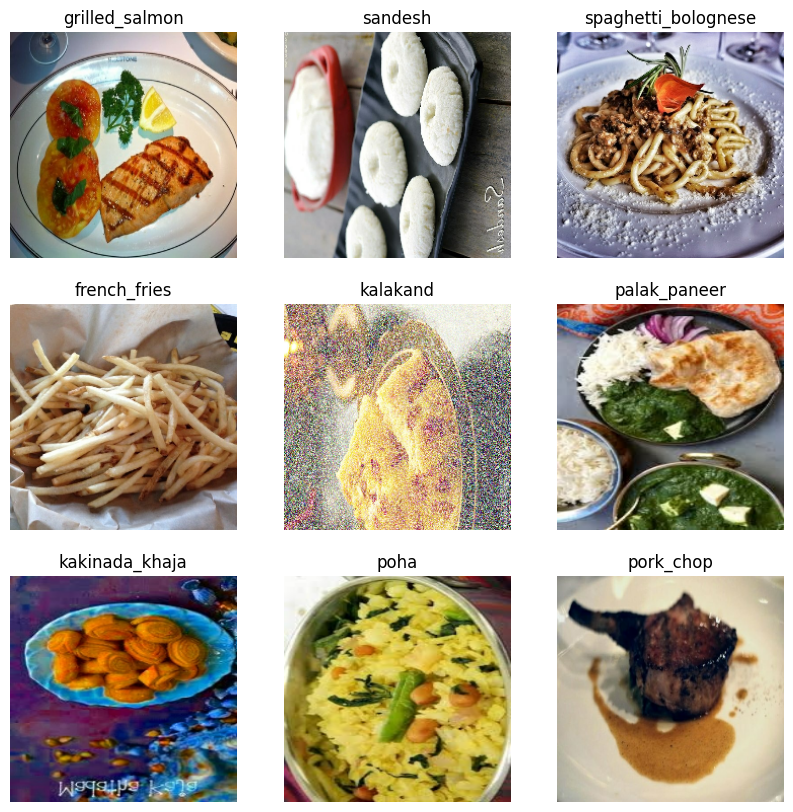

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_dir.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dir = train_dir.prefetch(buffer_size=AUTOTUNE)
test_dir = test_dir.prefetch(buffer_size=AUTOTUNE)

In [10]:
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [12]:
base_model.trainable = False

In [13]:
for image_batch, label_batch in train_dir.take(1):
    feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 7, 7, 1280)


In [14]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [15]:
prediction_layer = Dense(FOOD_CAT, activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 181)


In [16]:
x = base_model.input
x = base_model(x, training= False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.4)(x)
predictions = prediction_layer(x)

In [17]:
model = Model(inputs=base_model.input, outputs= predictions)

In [18]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 181)                 │         231,861 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,281,432 (16.33 MB)

 Trainable params: 231,861 (905.71 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

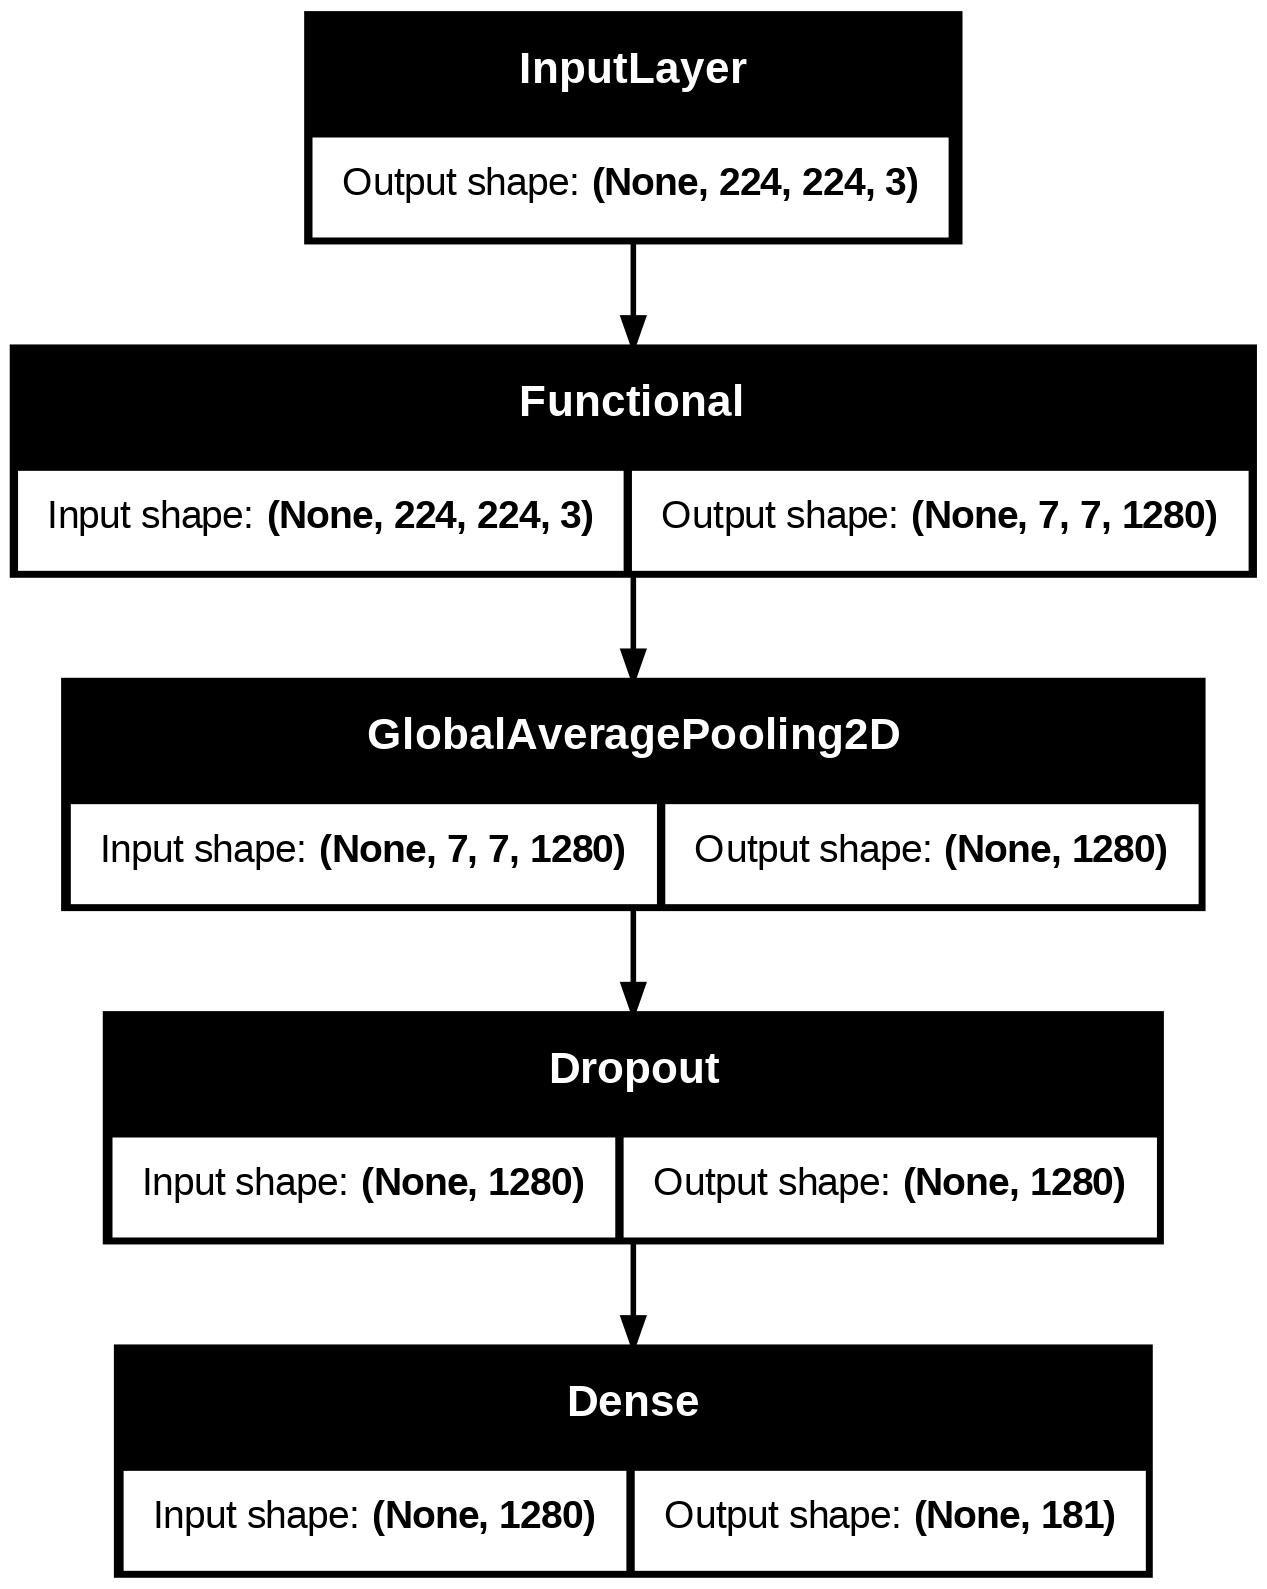

In [19]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_dir,
    validation_data= test_dir,
    epochs=10,
)

Epoch 1/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 212s 106ms/step - accuracy: 0.2889 - loss: 3.3405 - val_accuracy: 0.5603 - val_loss: 1.8230
Epoch 2/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 102s 56ms/step - accuracy: 0.5480 - loss: 1.8237 - val_accuracy: 0.6072 - val_loss: 1.5802
Epoch 3/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 102s 56ms/step - accuracy: 0.5957 - loss: 1.5953 - val_accuracy: 0.6314 - val_loss: 1.4723
Epoch 4/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 101s 56ms/step - accuracy: 0.6210 - loss: 1.4789 - val_accuracy: 0.6513 - val_loss: 1.4069
Epoch 5/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 101s 56ms/step - accuracy: 0.6336 - loss: 1.4036 - val_accuracy: 0.6564 - val_loss: 1.3736
Epoch 6/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 101s 56ms/step - accuracy: 0.6452 - loss: 1.3496 - val_accuracy: 0.6595 - val_loss: 1.3537
Epoch 7/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 101s 56ms/step - accuracy: 0.6511 - loss: 1.3133 - val_accuracy: 0.6654 - val_loss: 1.3320
Epoch 8/10
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 101s 56ms/step - accuracy:

In [22]:
loss, accuracy = model.evaluate(test_dir)
print(f"Test Accuracy: {accuracy:.2f}")

453/453 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.6760 - loss: 1.3011
Test Accuracy: 0.68


In [23]:
base_model.trainable = True

In [24]:
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  238


In [25]:
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [26]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001, decay_steps=1000, decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)


In [27]:
early_stop = EarlyStopping(
    monitor= "val_loss",
    patience= 7,
    restore_best_weights= True,
    start_from_epoch= 10,)

In [28]:
checkpoint = tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy")

In [29]:
model.compile(
    optimizer= optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history_finetune = model.fit(
    train_dir,
    validation_data= test_dir,
    epochs= 30,
    callbacks= [early_stop, checkpoint]
    )

Epoch 1/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 234s 103ms/step - accuracy: 0.5121 - loss: 1.9412 - val_accuracy: 0.6972 - val_loss: 1.1548
Epoch 2/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 205s 85ms/step - accuracy: 0.7115 - loss: 1.0549 - val_accuracy: 0.7418 - val_loss: 0.9996
Epoch 3/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 154s 85ms/step - accuracy: 0.7959 - loss: 0.7209 - val_accuracy: 0.7771 - val_loss: 0.8981
Epoch 4/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 154s 85ms/step - accuracy: 0.8597 - loss: 0.4789 - val_accuracy: 0.7881 - val_loss: 0.8988
Epoch 5/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 155s 86ms/step - accuracy: 0.9070 - loss: 0.3143 - val_accuracy: 0.7957 - val_loss: 0.8803
Epoch 6/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 155s 86ms/step - accuracy: 0.9389 - loss: 0.2059 - val_accuracy: 0.7997 - val_loss: 0.9272
Epoch 7/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 155s 85ms/step - accuracy: 0.9534 - loss: 0.1585 - val_accuracy: 0.8067 - val_loss: 0.9032
Epoch 8/30
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 155s 86ms/step - accuracy:

In [32]:
test_loss, test_accuracy = model.evaluate(test_dir)
print(f"Test Accuracy: {test_accuracy:.2f}")

453/453 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.8217 - loss: 0.9029
Test Accuracy: 0.82


In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(50, 50))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_dir:  
    predictions = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

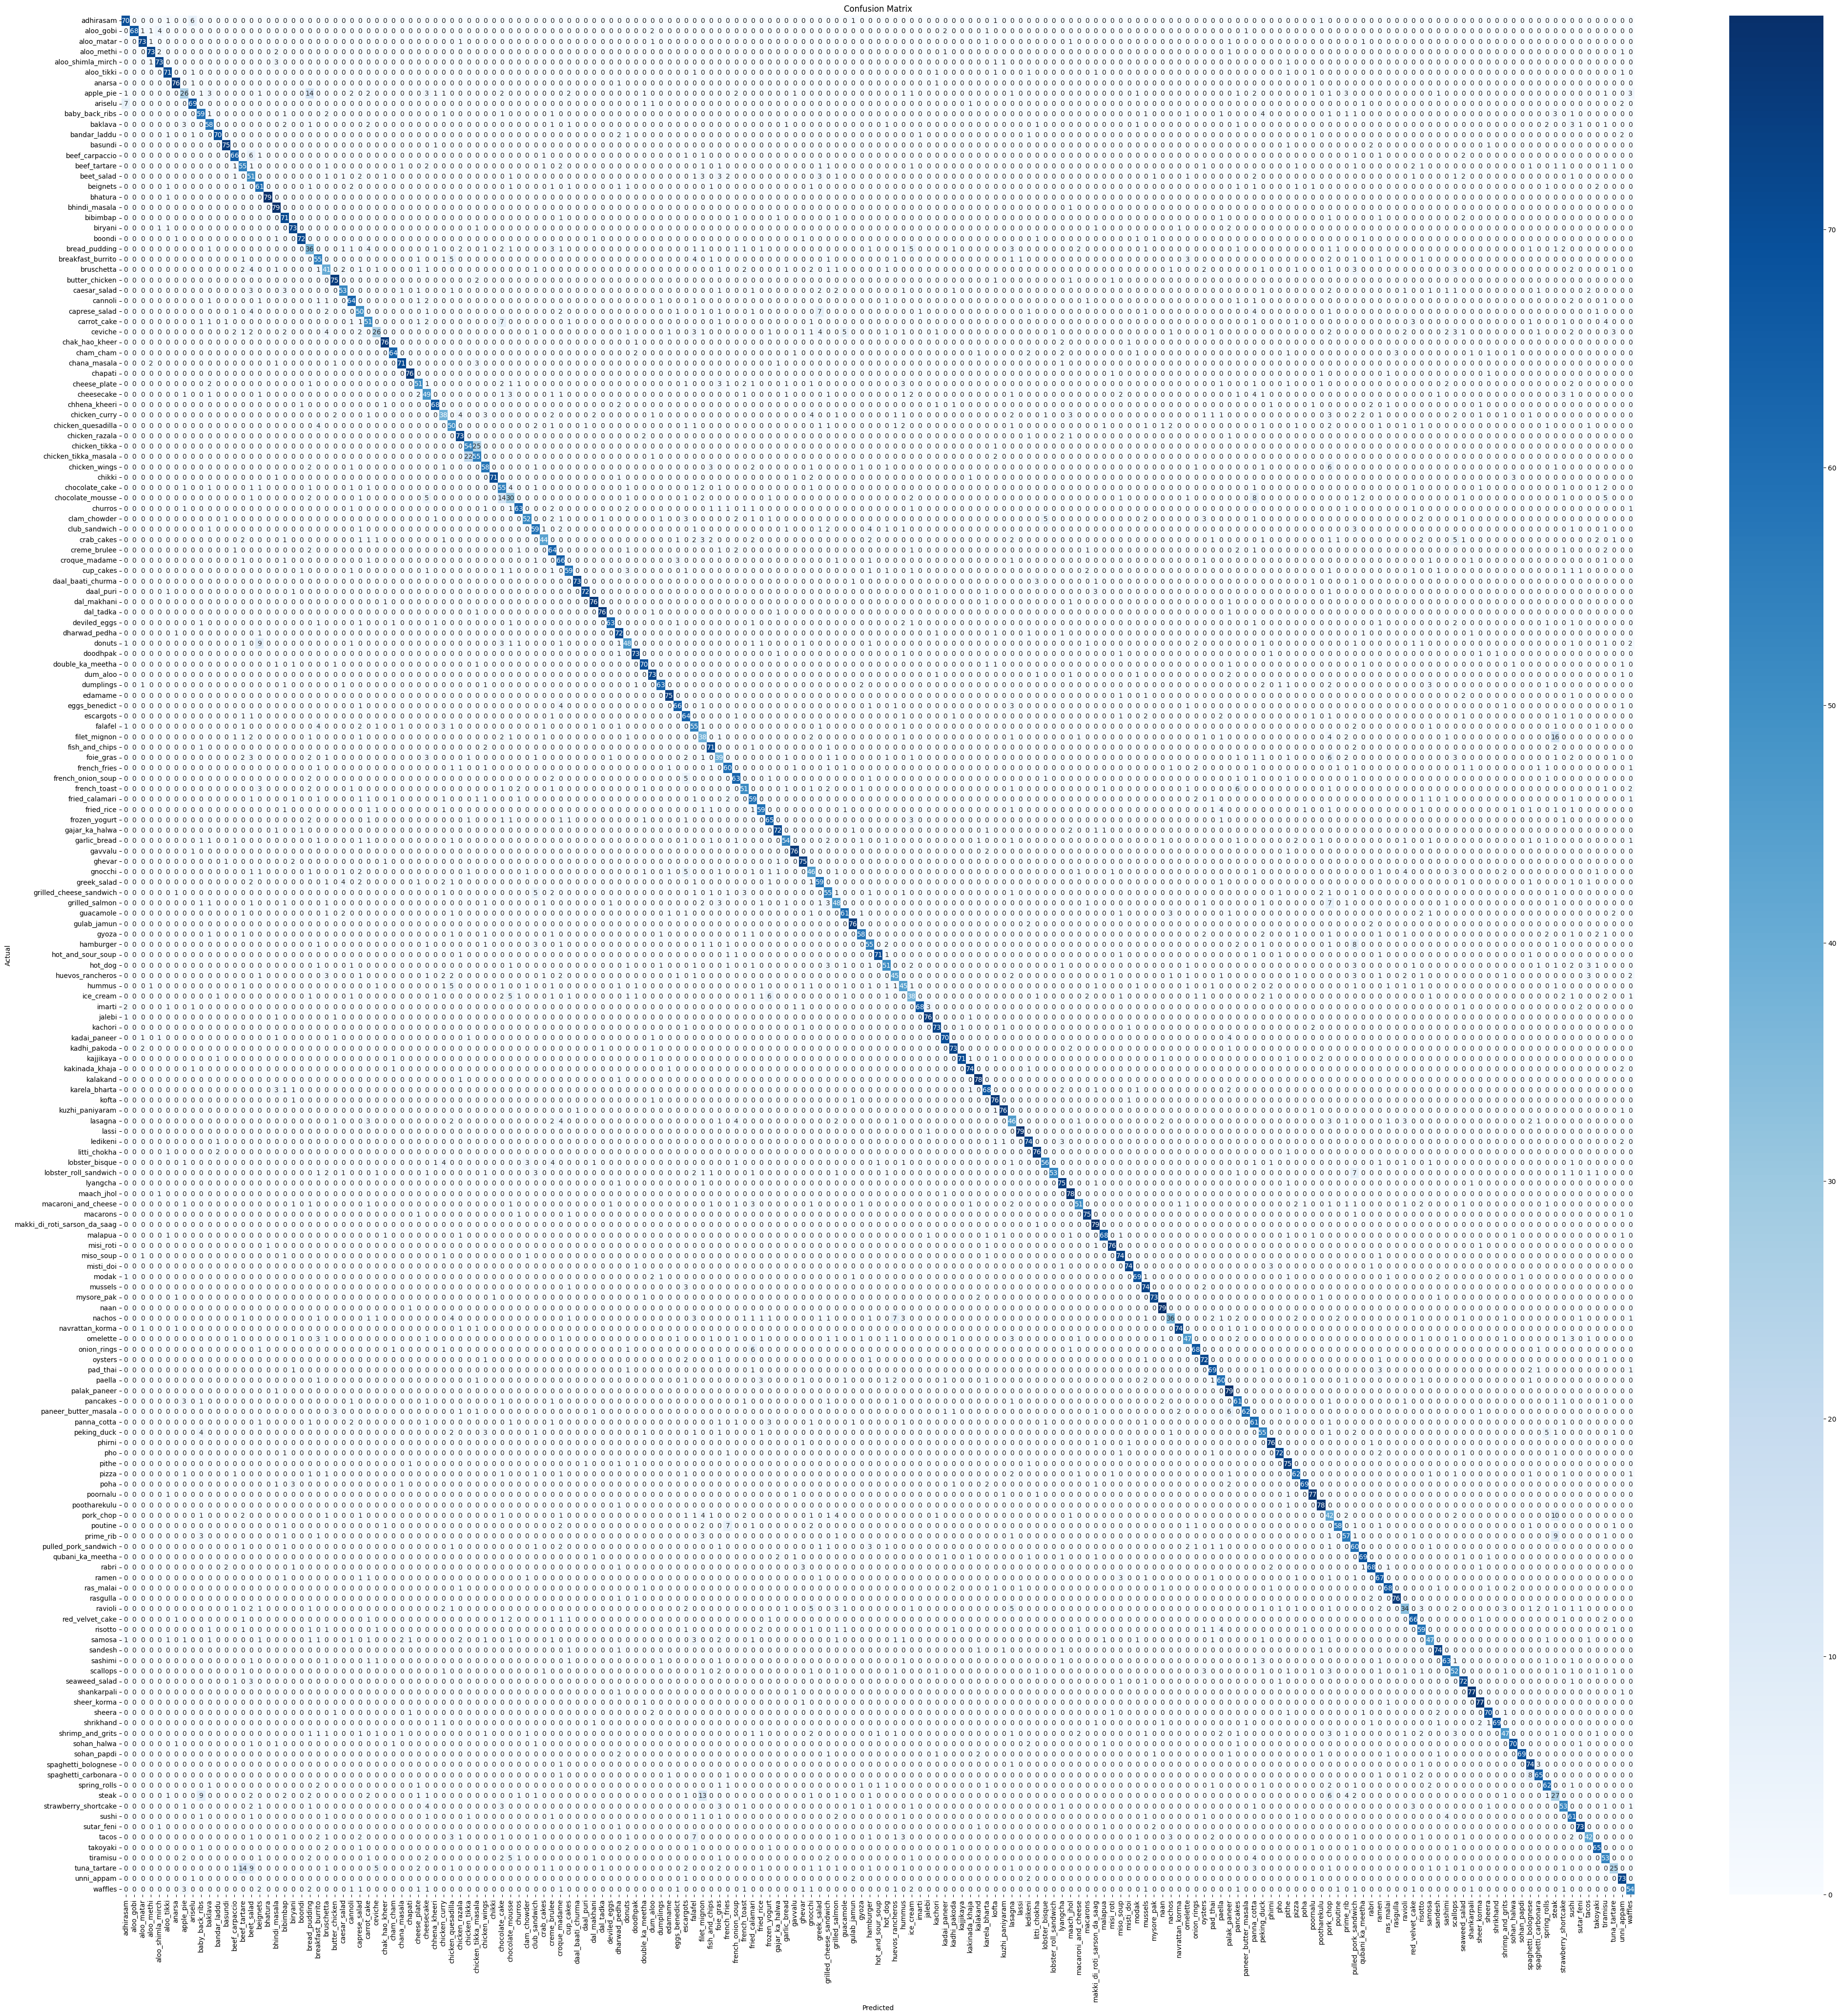

In [ ]:
plot_confusion_matrix(y_true, y_pred, class_names)

In [ ]:
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                              precision    recall  f1-score   support

                   adhirasam       0.82      0.88      0.85        80
                   aloo_gobi       1.00      0.85      0.92        80
                  aloo_matar       0.91      0.91      0.91        80
                  aloo_methi       0.92      0.91      0.92        80
           aloo_shimla_mirch       0.88      0.91      0.90        80
                  aloo_tikki       0.86      0.89      0.87        80
                      anarsa       0.92      0.95      0.93        80
                   apple_pie       0.58      0.33      0.42        80
                     ariselu       0.84      0.84      0.84        82
              baby_back_ribs       0.69      0.74      0.72        80
                     baklava       0.76      0.72      0.74        80
                bandar_laddu       0.93      0.88      0.90        80
                     basundi       0.94      0.94      0.94       